# Лабораторная работа №4
## Выполнили: Ячменников, Александров

In [1]:
import numpy as np

from adam import Adam
from sln import SLN
from perceptron import Perceptron

from sklearn.datasets import make_moons, make_classification

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
def plot_metrics_history(metrics_history, model_name="", dataset_name=""):
    fig = plt.figure(figsize=(15, 8))
    gs = GridSpec(2, 6, figure=fig)

    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 0:3]),
        fig.add_subplot(gs[1, 3:6]),
    ]

    for i, (metric, history) in enumerate(metrics_history.items()):
        axes[i].plot(history)
        axes[i].set_title(metric)
        axes[i].set_xlabel("epoch")
        axes[i].set_ylabel("metric value")
        axes[i].grid(True)

    fig.suptitle(f"Динамика значений метрик во время обучения. Модель: {model_name}. Данные: {dataset_name}")
    
    plt.tight_layout()
    plt.show()

In [3]:
def print_test_metrics(test_metrics):
    print("Test metrics")
    print("-"*20)
    print(f"Loss: {test_metrics['loss']:.4f}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall: {test_metrics['recall']:.4f}")
    print(f"F-1: {test_metrics['f1']:.4f}")

In [30]:
def make_validation_table(val_results):
    df = pd.DataFrame(val_results)
    display(df)

### Визуализация наборов данных

In [4]:
X_moons, y_moons = make_moons(n_samples=400, noise=0.15, random_state=468202)

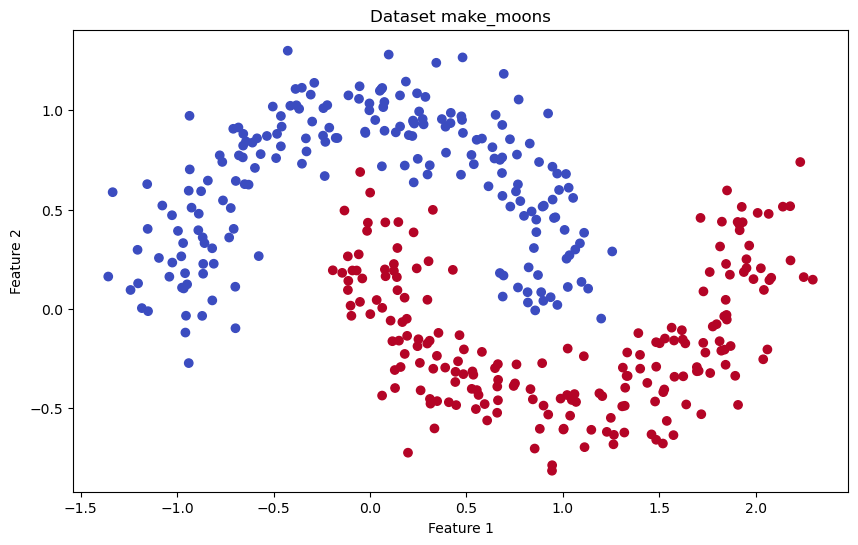

In [5]:
plt.figure(figsize=(10,6))

plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons, cmap='coolwarm')

plt.title("Dataset make_moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [6]:
X_class, y_class = make_classification(n_samples=200, n_features=5, n_redundant=2, random_state=468202, n_informative=2, n_clusters_per_class = 2, n_classes=2)   

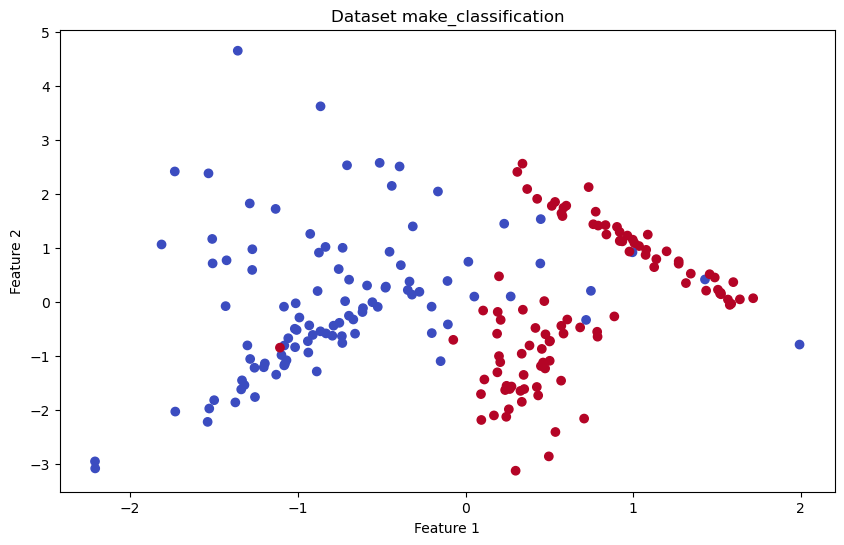

In [7]:
plt.figure(figsize=(10,6))

plt.scatter(X_class[:,0], X_class[:,1], c=y_class, cmap='coolwarm')

plt.title("Dataset make_classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

### Разделение на train (60%), validation(20%), test(20%)

In [8]:
def make_train_val_test(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [9]:
X_train_moons, X_val_moons, X_test_moons, y_train_moons, y_val_moons, y_test_moons = make_train_val_test(X_moons, y_moons)

X_train_class, X_val_class, X_test_class, y_train_class, y_val_class, y_test_class = make_train_val_test(X_class, y_class)

### Нормализация данных

In [10]:
def normalize_data(X_train, X_val, X_test):
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test

In [11]:
X_train_moons, X_val_moons, X_test_moons = normalize_data(X_train_moons, X_val_moons, X_test_moons)

X_train_class, X_val_class, X_test_class = normalize_data(X_train_class, X_val_class, X_test_class)

### SLN

#### make_moons

##### Валидация

In [13]:
sln = SLN(input_size=X_moons.shape[1])

learning_rates = [1e-2, 1e-3, 1e-5]
batch_sizes = [16, 32, 64]

sln_val = sln.hyperparameter_validation(X_train_moons, y_train_moons, X_val_moons, y_val_moons, learning_rates, batch_sizes, epochs=100)

make_validation_table(sln_val)

,lr,batch_size,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,0.01000,16,0.587311,0.5,0.5,1.0,0.666667
1,0.01000,32,0.581760,0.5,0.5,1.0,0.666667
2,0.01000,64,0.580880,0.5,0.5,1.0,0.666667
3,0.00100,16,0.579790,0.5,0.5,1.0,0.666667
4,0.00100,32,0.581067,0.5,0.5,1.0,0.666667
5,0.00100,64,0.583468,0.5,0.5,1.0,0.666667
6,0.00001,16,0.666021,0.5,0.5,1.0,0.666667
7,0.00001,32,0.668895,0.5,0.5,1.0,0.666667
8,0.00001,64,0.670768,0.5,0.5,1.0,0.666667


##### Обучение

In [14]:
sln_moons_lr = 1e-3
sln_moons_b_s = 16

sln = SLN(input_size=X_moons.shape[1])
sln_adam = Adam(parameters=sln.parameters(), lr=sln_moons_lr)

sln_moons_train_hist = sln.fit(X_train_moons, y_train_moons, sln_adam, batch_size=sln_moons_b_s, epochs=100, print_epoch_k=10)

Epoch: 10, loss: 0.6004, f1: 0.6592
Epoch: 20, loss: 0.5709, f1: 0.6592
Epoch: 30, loss: 0.5653, f1: 0.6592
Epoch: 40, loss: 0.5633, f1: 0.6592
Epoch: 50, loss: 0.5625, f1: 0.6592
Epoch: 60, loss: 0.5618, f1: 0.6592
Epoch: 70, loss: 0.5613, f1: 0.6592
Epoch: 80, loss: 0.5611, f1: 0.6592
Epoch: 90, loss: 0.5609, f1: 0.6592
Epoch: 100, loss: 0.5607, f1: 0.6592


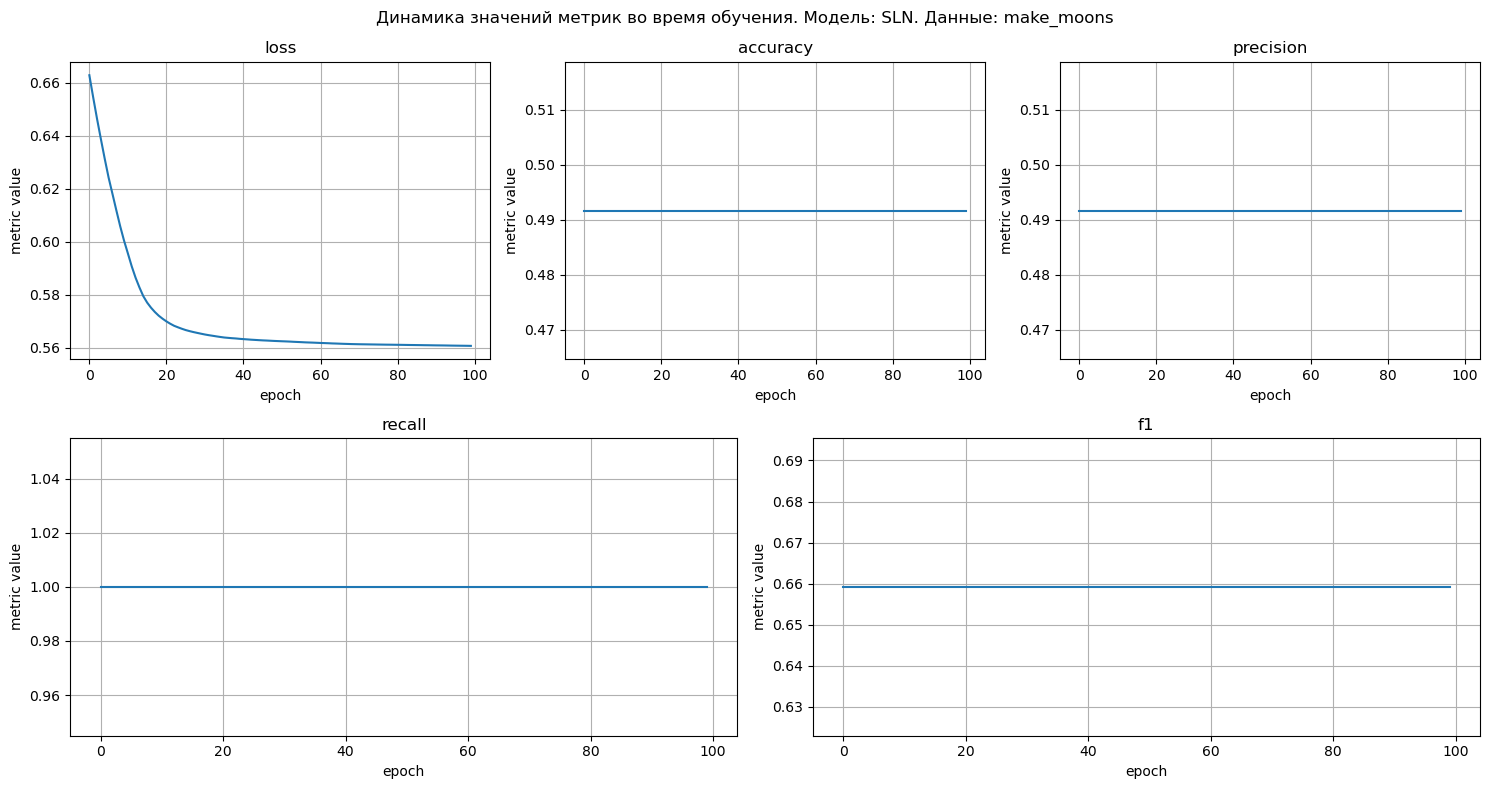

In [15]:
plot_metrics_history(sln_moons_train_hist, "SLN", "make_moons")

##### Тест

In [16]:
sln_moons_test_pred = sln.predict_proba(X_test_moons)

sln_moons_test_metrics = sln.calculate_metrics(
    y_test_moons,
    sln_moons_test_pred
)

print_test_metrics(sln_moons_test_metrics)

Test metrics
--------------------
Loss: 0.5528
Accuracy: 0.5250
Precision: 0.5250
Recall: 1.0000
F-1: 0.6885


#### make_classification

##### Валидация

In [17]:
sln = SLN(input_size=X_class.shape[1])

learning_rates = [1e-2, 1e-3, 1e-5]
batch_sizes = [16, 32, 64]

sln_val = sln.hyperparameter_validation(X_train_class, y_train_class, X_val_class, y_val_class, learning_rates, batch_sizes, epochs=100)

make_validation_table(sln_val)

,lr,batch_size,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,0.01000,16,0.572557,0.45,0.45,1.0,0.62069
1,0.01000,32,0.572733,0.45,0.45,1.0,0.62069
2,0.01000,64,0.570847,0.45,0.45,1.0,0.62069
3,0.00100,16,0.570614,0.45,0.45,1.0,0.62069
4,0.00100,32,0.573816,0.45,0.45,1.0,0.62069
5,0.00100,64,0.585394,0.45,0.45,1.0,0.62069
6,0.00001,16,0.660436,0.45,0.45,1.0,0.62069
7,0.00001,32,0.662211,0.45,0.45,1.0,0.62069
8,0.00001,64,0.663296,0.45,0.45,1.0,0.62069


##### Обучение

In [18]:
sln_class_lr = 1e-3
sln_class_b_s = 16

sln = SLN(input_size=X_class.shape[1])
sln_adam = Adam(parameters=sln.parameters(), lr=sln_class_lr)

sln_class_train_hist = sln.fit(X_train_class, y_train_class, sln_adam, batch_size=sln_class_b_s, epochs=100, print_epoch_k=10)

Epoch: 10, loss: 0.6199, f1: 0.6667
Epoch: 20, loss: 0.5836, f1: 0.6667
Epoch: 30, loss: 0.5642, f1: 0.6667
Epoch: 40, loss: 0.5514, f1: 0.6667
Epoch: 50, loss: 0.5447, f1: 0.6667
Epoch: 60, loss: 0.5417, f1: 0.6667
Epoch: 70, loss: 0.5399, f1: 0.6667
Epoch: 80, loss: 0.5387, f1: 0.6667
Epoch: 90, loss: 0.5377, f1: 0.6667
Epoch: 100, loss: 0.5370, f1: 0.6667


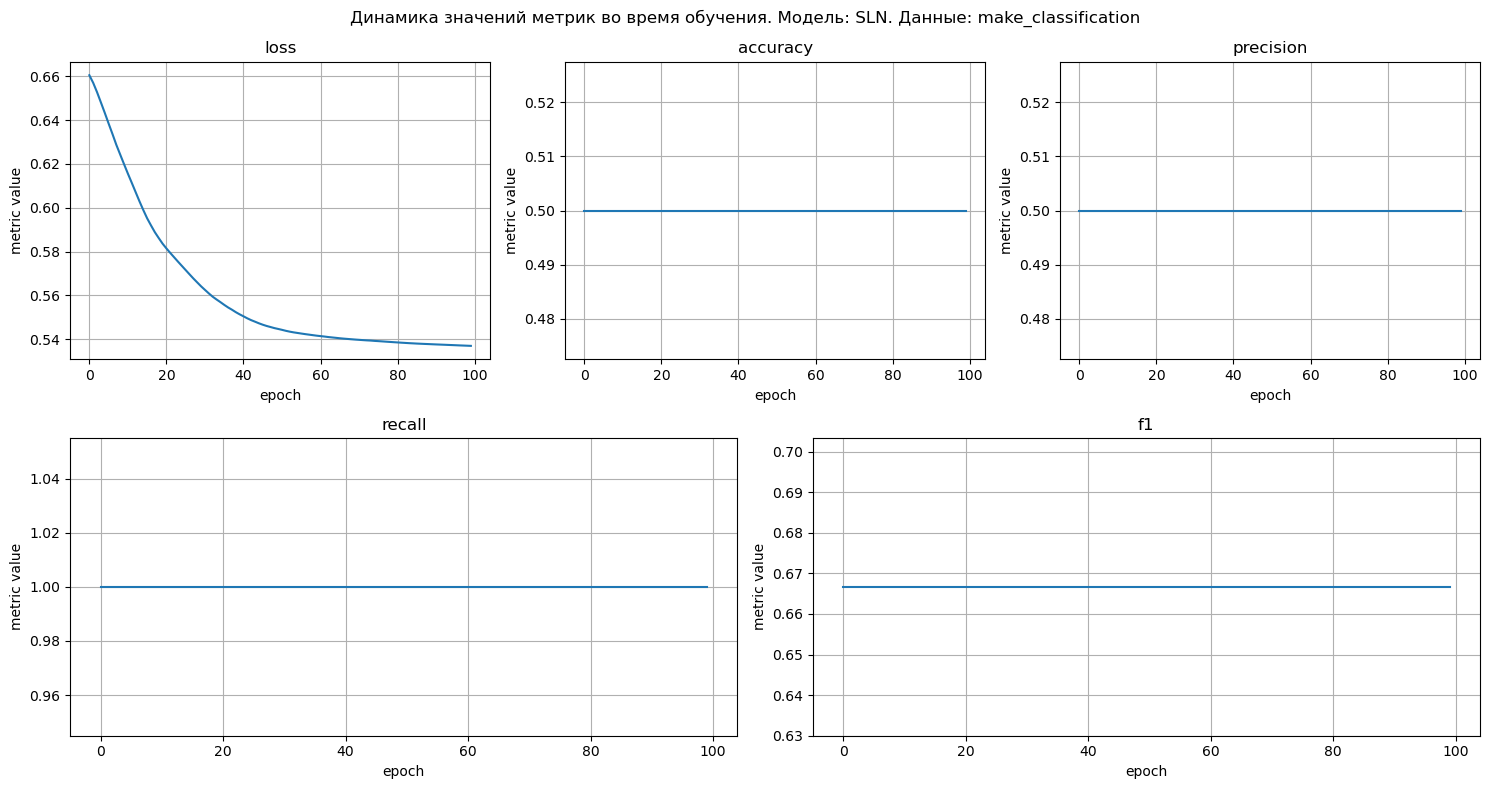

In [19]:
plot_metrics_history(sln_class_train_hist, "SLN", "make_classification")

##### Тест

In [20]:
sln_class_test_pred = sln.predict_proba(X_test_class)

sln_class_test_metrics = sln.calculate_metrics(
    y_test_class,
    sln_class_test_pred
)

print_test_metrics(sln_class_test_metrics)

Test metrics
--------------------
Loss: 0.5383
Accuracy: 0.5500
Precision: 0.5500
Recall: 1.0000
F-1: 0.7097


### Perceptron

### make_moons

##### Валидация

In [21]:
perceptron = Perceptron(input_size=X_moons.shape[1])

hidden_sizes = [5, 10, 20]
learning_rates = [1e-2, 1e-3, 1e-5]
batch_sizes = [16, 32, 64]

perceptron_val = perceptron.hyperparameter_validation(X_train_moons, y_train_moons, X_val_moons, y_val_moons, hidden_sizes, learning_rates, batch_sizes, epochs=100)

make_validation_table(perceptron_val)

,hidden_size,lr,batch_size,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,5,0.01000,16,0.324307,0.8375,0.829268,0.850,0.839506
1,5,0.01000,32,0.314960,0.8375,0.813953,0.875,0.843373
2,5,0.01000,64,0.318557,0.8375,0.813953,0.875,0.843373
3,5,0.00100,16,0.333636,0.8375,0.813953,0.875,0.843373
4,5,0.00100,32,0.348591,0.8250,0.795455,0.875,0.833333
5,5,0.00100,64,0.375958,0.8500,0.804348,0.925,0.860465
6,5,0.00001,16,0.686068,0.6625,0.600000,0.975,0.742857
7,5,0.00001,32,0.687826,0.6625,0.600000,0.975,0.742857
8,5,0.00001,64,0.688959,0.6000,0.558824,0.950,0.703704
9,10,0.01000,16,0.319951,0.8375,0.800000,0.900,0.847059


##### Обучение

In [22]:
perceptron_moons_h_s = 20
perceptron_moons_lr = 1e-2
perceptron_moons_b_s = 32

perceptron = Perceptron(input_size=X_moons.shape[1], hidden_size=perceptron_moons_h_s)
perceptron_adam = Adam(parameters=perceptron.parameters(), lr=perceptron_moons_lr)

perceptron_moons_train_hist = perceptron.fit(X_train_moons, y_train_moons, perceptron_adam, batch_size=perceptron_moons_b_s, epochs=100, print_epoch_k=10)

Epoch: 10, loss: 0.2298, f1: 0.8803
Epoch: 20, loss: 0.1574, f1: 0.9356
Epoch: 30, loss: 0.0724, f1: 0.9829
Epoch: 40, loss: 0.0455, f1: 0.9915
Epoch: 50, loss: 0.0331, f1: 0.9915
Epoch: 60, loss: 0.0273, f1: 0.9957
Epoch: 70, loss: 0.0228, f1: 0.9957
Epoch: 80, loss: 0.0205, f1: 0.9957
Epoch: 90, loss: 0.0178, f1: 0.9957
Epoch: 100, loss: 0.0166, f1: 0.9957


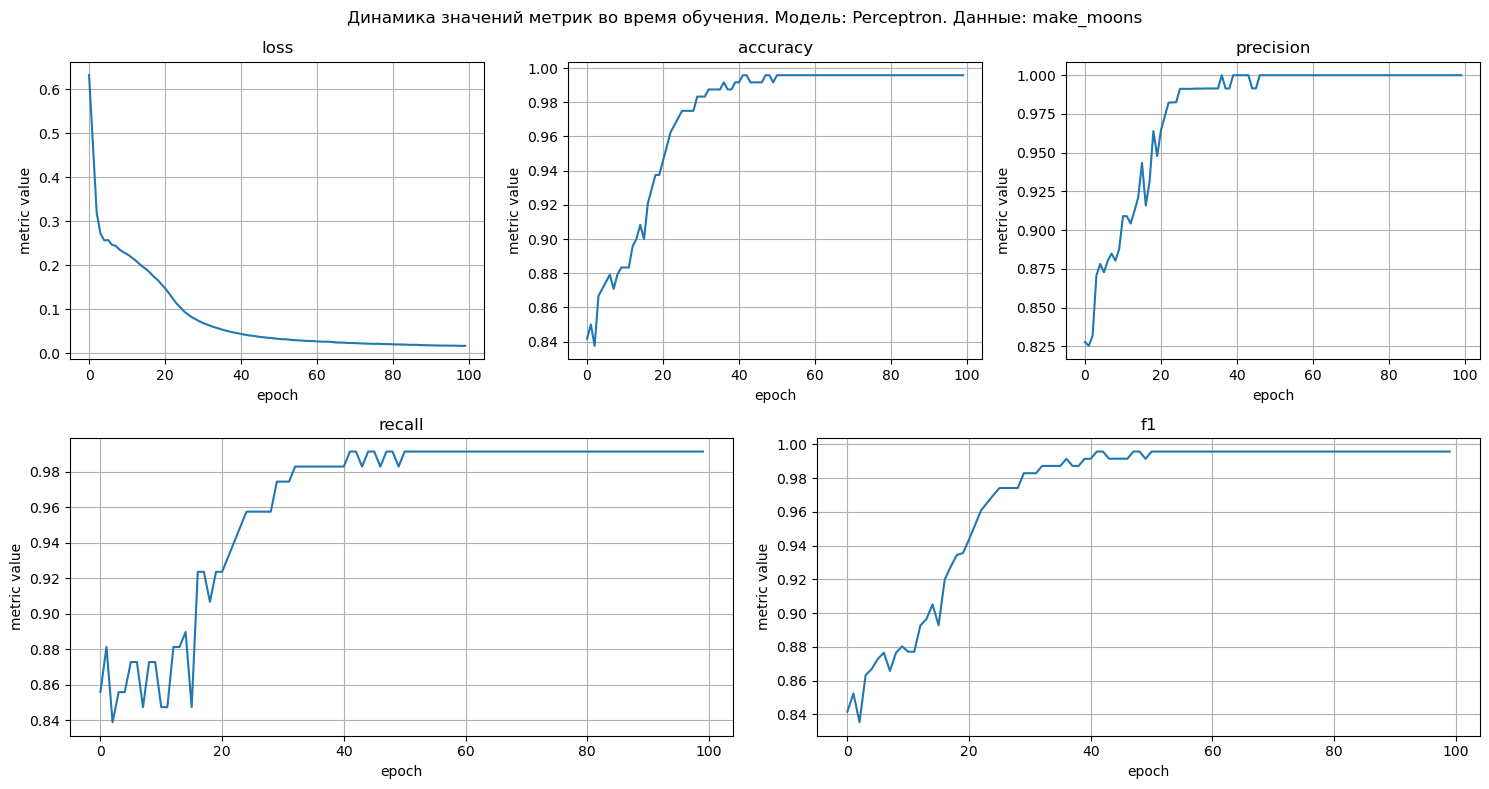

In [23]:
plot_metrics_history(perceptron_moons_train_hist, "Perceptron", "make_moons")

##### Тест

In [24]:
perceptron_moons_test_pred = perceptron.predict_proba(X_test_moons)

perceptron_moons_test_metrics = perceptron.calculate_metrics(
    y_test_moons,
    perceptron_moons_test_pred
)

print_test_metrics(perceptron_moons_test_metrics)

Test metrics
--------------------
Loss: 0.0055
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F-1: 1.0000


#### make_classification

##### Валидация

In [25]:
perceptron = Perceptron(input_size=X_class.shape[1])

hidden_sizes = [5, 10, 20]
learning_rates = [1e-2, 1e-3, 1e-5]
batch_sizes = [16, 32, 64]

perceptron_val = perceptron.hyperparameter_validation(X_train_class, y_train_class, X_val_class, y_val_class, hidden_sizes, learning_rates, batch_sizes, epochs=100)

make_validation_table(perceptron_val)

,hidden_size,lr,batch_size,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,5,0.01000,16,0.219500,0.900,0.818182,1.000000,0.900000
1,5,0.01000,32,0.207391,0.900,0.818182,1.000000,0.900000
2,5,0.01000,64,0.215252,0.900,0.818182,1.000000,0.900000
3,5,0.00100,16,0.257491,0.900,0.818182,1.000000,0.900000
4,5,0.00100,32,0.279984,0.900,0.818182,1.000000,0.900000
5,5,0.00100,64,0.401447,0.900,0.818182,1.000000,0.900000
6,5,0.00001,16,0.693090,0.450,0.450000,1.000000,0.620690
7,5,0.00001,32,0.694119,0.450,0.450000,1.000000,0.620690
8,5,0.00001,64,0.694815,0.450,0.450000,1.000000,0.620690
9,10,0.01000,16,0.201465,0.925,0.857143,1.000000,0.923077


##### Обучение

In [26]:
perceptron_class_h_s = 20
perceptron_class_lr = 1e-2
perceptron_class_b_s = 32

perceptron = Perceptron(input_size=X_class.shape[1], hidden_size=perceptron_class_h_s)
perceptron_adam = Adam(parameters=perceptron.parameters(), lr=perceptron_class_lr)

perceptron_class_train_hist = perceptron.fit(X_train_class, y_train_class, perceptron_adam, batch_size=perceptron_class_b_s, epochs=100, print_epoch_k=10)

Epoch: 10, loss: 0.1825, f1: 0.9593
Epoch: 20, loss: 0.1682, f1: 0.9593
Epoch: 30, loss: 0.1556, f1: 0.9593
Epoch: 40, loss: 0.1468, f1: 0.9593
Epoch: 50, loss: 0.1393, f1: 0.9593
Epoch: 60, loss: 0.1333, f1: 0.9593
Epoch: 70, loss: 0.1284, f1: 0.9593
Epoch: 80, loss: 0.1253, f1: 0.9593
Epoch: 90, loss: 0.1225, f1: 0.9593
Epoch: 100, loss: 0.1189, f1: 0.9593


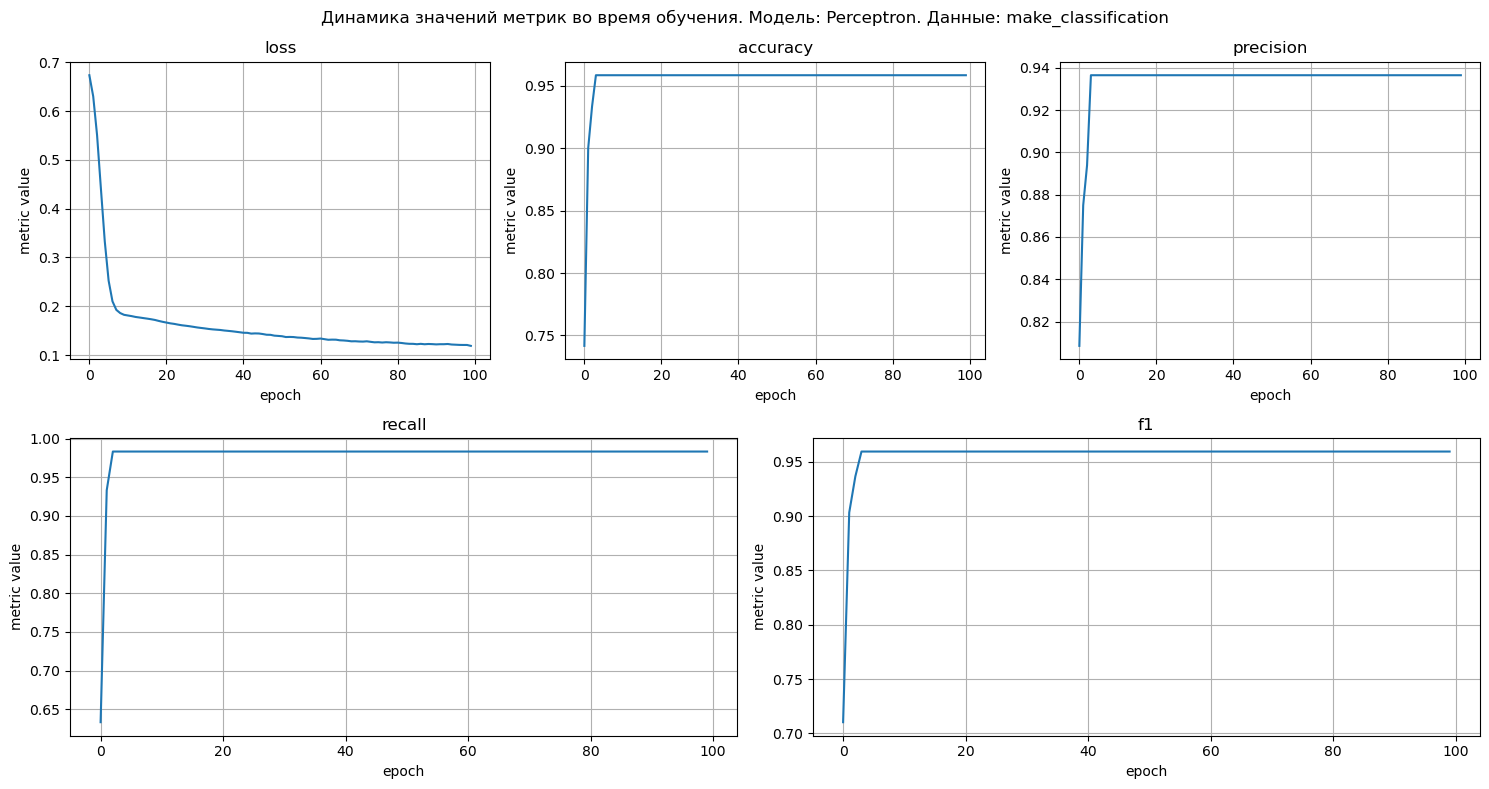

In [27]:
plot_metrics_history(perceptron_class_train_hist, "Perceptron", "make_classification")

##### Тест

In [28]:
perceptron_class_test_pred = perceptron.predict_proba(X_test_class)

perceptron_class_test_metrics = perceptron.calculate_metrics(
    y_test_class,
    perceptron_class_test_pred
)

print_test_metrics(perceptron_class_test_metrics)

Test metrics
--------------------
Loss: 0.2804
Accuracy: 0.9250
Precision: 0.9130
Recall: 0.9545
F-1: 0.9333
